In [3]:
import pandas as pd
import numpy as np

#  Step 1: Data Collection & Loading

In [4]:
df = pd.read_csv("/content/synthetic_disaster_events_2025 (1).csv")

In [ ]:
df

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster
0,1,Wildfire,Chile,-34.681672,-71.819529,2025-08-27,8,31104,2768213.39,5.12,Yes,0.59,1
1,2,Hurricane,India,22.128569,78.023951,2023-05-29,5,29340,5996226.87,44.43,No,0.26,0
2,3,Volcanic Eruption,Italy,42.316058,11.031447,2023-01-15,7,34804,9222541.48,49.30,No,0.94,1
3,4,Drought,Chile,-33.436253,-69.984615,2024-02-08,8,31191,1827703.09,65.56,Yes,0.94,1
4,5,Volcanic Eruption,Turkey,39.400977,37.006822,2023-12-23,8,46284,13435921.49,60.96,No,0.92,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,Volcanic Eruption,India,19.962542,82.590546,2025-11-16,6,28135,2556182.54,38.71,No,0.69,0
19996,19997,Volcanic Eruption,Japan,35.853659,138.522874,2025-04-08,2,4340,1228534.00,7.67,No,0.18,0
19997,19998,Hurricane,Philippines,13.720136,121.306074,2025-08-26,8,44663,8518260.66,9.76,Yes,0.75,1
19998,19999,Volcanic Eruption,India,19.959071,77.272460,2023-03-24,7,37484,10802942.53,13.87,Yes,0.77,1



 ## Dataset size


In [5]:
df.shape

(20000, 13)

##Column structure


In [ ]:
df.columns

Index(['event_id', 'disaster_type', 'location', 'latitude', 'longitude',
       'date', 'severity_level', 'affected_population',
       'estimated_economic_loss_usd', 'response_time_hours', 'aid_provided',
       'infrastructure_damage_index', 'is_major_disaster'],
      dtype='object')

In [ ]:
df.dtypes

,0
event_id,int64
disaster_type,object
location,object
latitude,float64
longitude,float64
date,object
severity_level,int64
affected_population,int64
estimated_economic_loss_usd,float64
response_time_hours,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   event_id                     20000 non-null  int64  
 1   disaster_type                20000 non-null  object 
 2   location                     20000 non-null  object 
 3   latitude                     20000 non-null  float64
 4   longitude                    20000 non-null  float64
 5   date                         20000 non-null  object 
 6   severity_level               20000 non-null  int64  
 7   affected_population          20000 non-null  int64  
 8   estimated_economic_loss_usd  20000 non-null  float64
 9   response_time_hours          20000 non-null  float64
 10  aid_provided                 20000 non-null  object 
 11  infrastructure_damage_index  20000 non-null  float64
 12  is_major_disaster            20000 non-null  int64  
dtypes: float64(5), i

# Step 2: Initial Data Inspection

In [ ]:
df.head()

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster
0,1,Wildfire,Chile,-34.681672,-71.819529,2025-08-27,8,31104,2768213.39,5.12,Yes,0.59,1
1,2,Hurricane,India,22.128569,78.023951,2023-05-29,5,29340,5996226.87,44.43,No,0.26,0
2,3,Volcanic Eruption,Italy,42.316058,11.031447,2023-01-15,7,34804,9222541.48,49.30,No,0.94,1
3,4,Drought,Chile,-33.436253,-69.984615,2024-02-08,8,31191,1827703.09,65.56,Yes,0.94,1
4,5,Volcanic Eruption,Turkey,39.400977,37.006822,2023-12-23,8,46284,13435921.49,60.96,No,0.92,1


In [ ]:
df.tail()

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster
19995,19996,Volcanic Eruption,India,19.962542,82.590546,2025-11-16,6,28135,2556182.54,38.71,No,0.69,0
19996,19997,Volcanic Eruption,Japan,35.853659,138.522874,2025-04-08,2,4340,1228534.00,7.67,No,0.18,0
19997,19998,Hurricane,Philippines,13.720136,121.306074,2025-08-26,8,44663,8518260.66,9.76,Yes,0.75,1
19998,19999,Volcanic Eruption,India,19.959071,77.272460,2023-03-24,7,37484,10802942.53,13.87,Yes,0.77,1
19999,20000,Landslide,Chile,-36.842195,-68.613505,2023-04-05,6,34441,8966848.02,4.01,Yes,0.60,0


In [ ]:
df.describe()

,event_id,latitude,longitude,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,infrastructure_damage_index,is_major_disaster
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.00000
mean,10000.500000,18.749811,41.976629,5.489300,27641.248950,4.831073e+06,36.369664,0.557306,0.40005
std,5773.647028,25.026759,82.535922,2.866269,16017.199074,3.624308e+06,20.420570,0.209064,0.48992
min,1.000000,-43.127383,-102.133704,1.000000,0.000000,0.000000e+00,1.000000,0.060000,0.00000
25%,5000.750000,3.560059,8.346726,3.000000,14755.000000,2.024090e+06,18.407500,0.400000,0.00000
50%,10000.500000,24.361006,74.600322,5.000000,27612.500000,4.031418e+06,36.560000,0.550000,0.00000
75%,15000.250000,38.285895,117.460836,8.000000,40016.500000,7.018268e+06,54.020000,0.700000,1.00000
max,20000.000000,48.452161,145.902669,10.000000,75147.000000,2.186893e+07,71.990000,1.000000,1.00000


In [ ]:
df.isnull().sum()

,0
event_id,0
disaster_type,0
location,0
latitude,0
longitude,0
date,0
severity_level,0
affected_population,0
estimated_economic_loss_usd,0
response_time_hours,0


In [ ]:
df.nunique()

,0
event_id,20000
disaster_type,7
location,8
latitude,20000
longitude,20000
date,1096
severity_level,10
affected_population,16323
estimated_economic_loss_usd,19177
response_time_hours,6661


In [ ]:
df.duplicated().sum()

np.int64(0)

#Step 3: Data Cleaning


## Handle missing values

- There are no missing values in the dataset.


## Remove duplicates
- There are no duplicates in the dataset

 ## Fix incorrect data types

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df['aid_provided'] = df['aid_provided'].astype('category')
df['disaster_type'] = df['disaster_type'].astype('category')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   event_id                     20000 non-null  int64         
 1   disaster_type                20000 non-null  category      
 2   location                     20000 non-null  object        
 3   latitude                     20000 non-null  float64       
 4   longitude                    20000 non-null  float64       
 5   date                         20000 non-null  datetime64[ns]
 6   severity_level               20000 non-null  int64         
 7   affected_population          20000 non-null  int64         
 8   estimated_economic_loss_usd  20000 non-null  float64       
 9   response_time_hours          20000 non-null  float64       
 10  aid_provided                 20000 non-null  category      
 11  infrastructure_damage_index  20000 non-nu

## Standardize column names
- All column names were already lowercase and snake_case — no changes needed.

#Step 4: Exploratory Data Analysis (EDA)


##Univariate Analysis


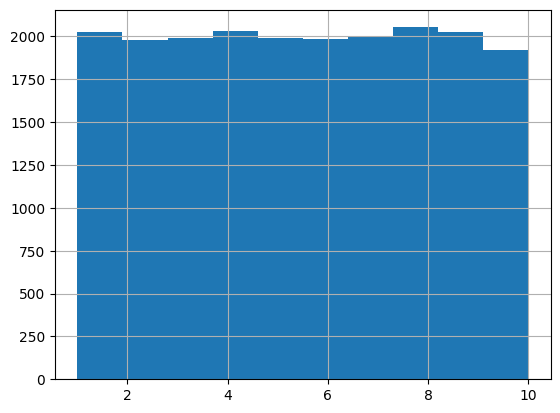

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df['severity_level'].hist()
plt.show()

## Insight
- Severity levels are distributed across the dataset

- Most disaster events fall in medium severity range

- Distribution appears fairly balanced

- No extreme skewness observed

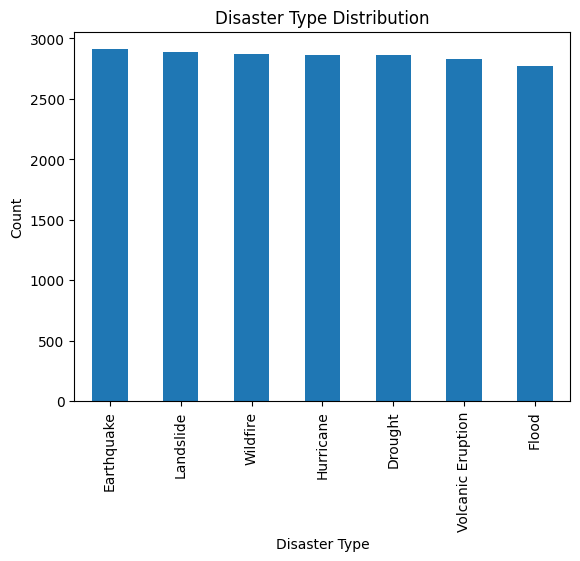

In [ ]:
df['disaster_type'].value_counts().plot(kind='bar')
plt.title("Disaster Type Distribution")
plt.xlabel("Disaster Type")
plt.ylabel("Count")
plt.show()

## Insight
- All 7 disaster types are roughly equal in count (~2857 each) — balanced dataset, no single disaster dominates

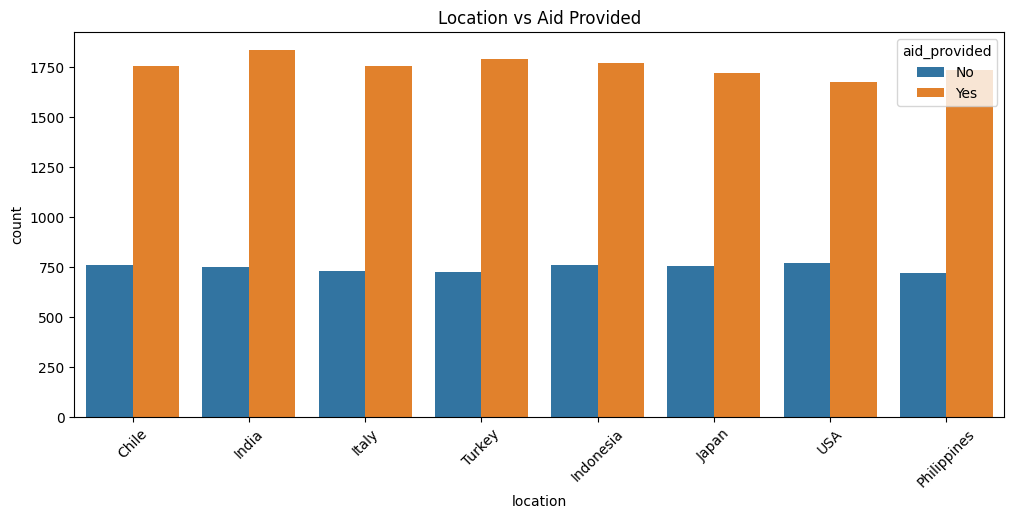

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='location',
    hue='aid_provided',
    data=df
)

plt.title("Location vs Aid Provided")
plt.xticks(rotation=45)
plt.show()

## Insight
- Aid is provided fairly consistently across all locations — no location is significantly neglected or over-served

## Bivariate Analysis

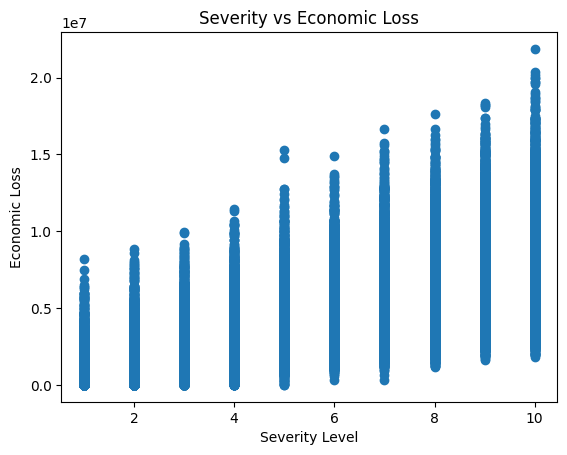

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['severity_level'], df['estimated_economic_loss_usd'])
plt.xlabel("Severity Level")
plt.ylabel("Economic Loss")
plt.title("Severity vs Economic Loss")
plt.show()

## Insight
- The scatter plot shows no strong linear relationship between severity level and economic loss. Although some severe disasters cause high losses, higher severity does not always result in greater economic damage, indicating that other factors also influence economic loss.

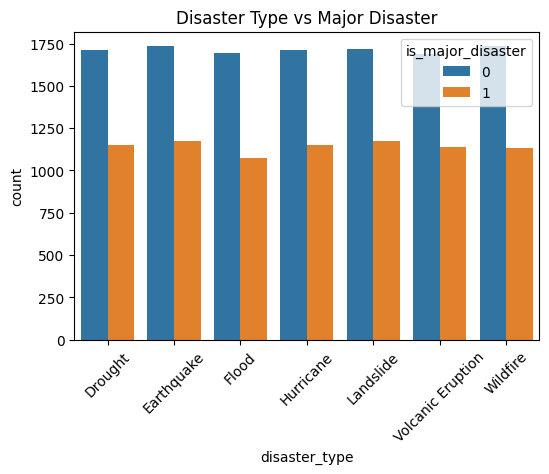

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='disaster_type',
    hue='is_major_disaster',
    data=df
)

plt.title("Disaster Type vs Major Disaster")
plt.xticks(rotation=45)
plt.show()

## Insight
- All disaster types have similar proportions of major vs non-major events — no single disaster type is exclusively major

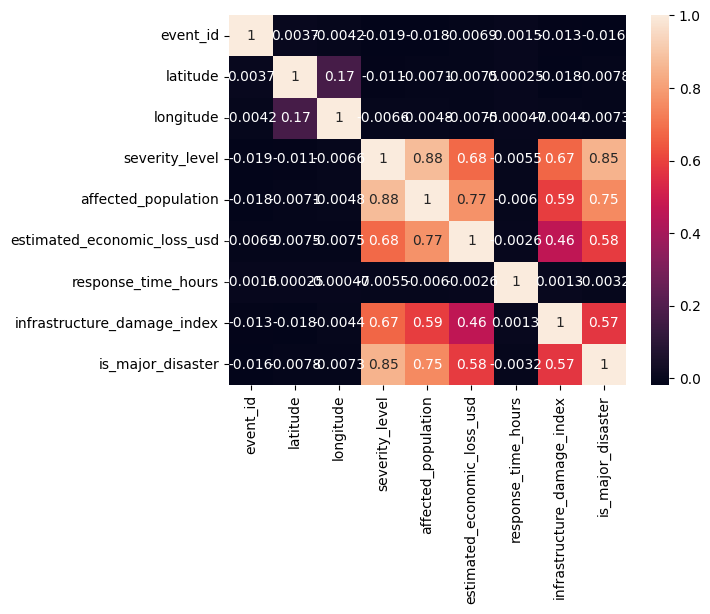

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## Insight
- Very low correlations between all numerical features — features are largely independent of each other, which is good for avoiding multicollinearity

## Multivariate Analysis

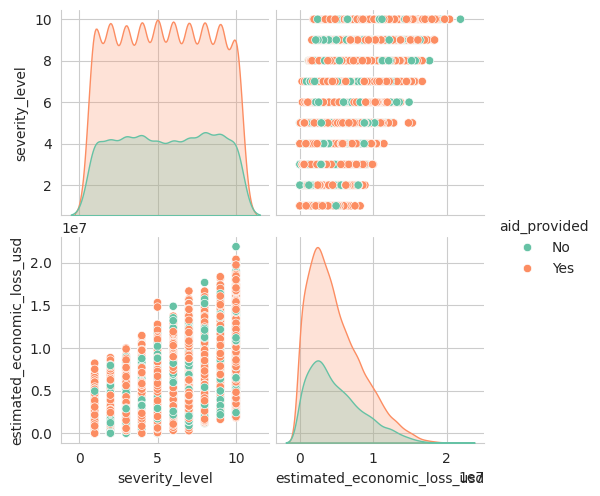

In [ ]:
# Columns for pairplot
cols = [
    'severity_level',
    'estimated_economic_loss_usd',
    'aid_provided'
]

# Set style
sns.set_style("whitegrid")

# Create colorful pairplot
sns.pairplot(
    df[cols],
    hue='aid_provided',
    palette='Set2',
    diag_kind='kde'
)

plt.show()

## Insight
- No clear cluster separation between aid provided groups — aid_provided doesn't strongly depend on severity or economic loss alone



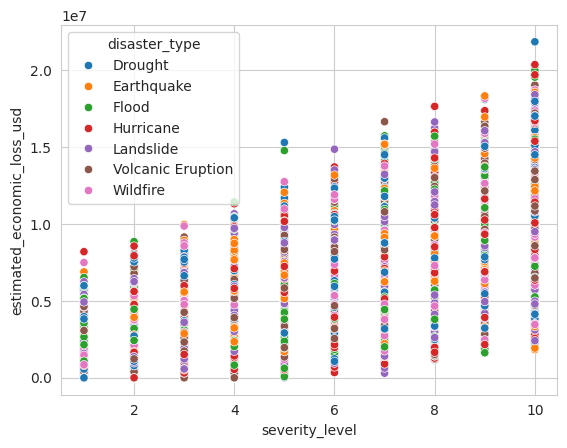

In [ ]:
sns.scatterplot(
    x='severity_level',
    y='estimated_economic_loss_usd',
    hue='disaster_type',
    data=df
)
plt.show()

##Insight

- Shows how disaster type affects relationship between severity and economic loss

- Different disaster types show different economic impact patterns

- Useful for understanding interaction effects

#Step 5: Outlier Detection & Treatment

In [ ]:
df.describe()

,event_id,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,infrastructure_damage_index,is_major_disaster
count,20000.000000,20000.000000,20000.000000,20000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.00000
mean,10000.500000,18.749811,41.976629,2024-06-11 03:20:26.880000,5.489300,27641.248950,4.831073e+06,36.369664,0.557306,0.40005
min,1.000000,-43.127383,-102.133704,2022-12-08 00:00:00,1.000000,0.000000,0.000000e+00,1.000000,0.060000,0.00000
25%,5000.750000,3.560059,8.346726,2023-09-09 00:00:00,3.000000,14755.000000,2.024090e+06,18.407500,0.400000,0.00000
50%,10000.500000,24.361006,74.600322,2024-06-14 00:00:00,5.000000,27612.500000,4.031418e+06,36.560000,0.550000,0.00000
75%,15000.250000,38.285895,117.460836,2025-03-13 00:00:00,8.000000,40016.500000,7.018268e+06,54.020000,0.700000,1.00000
max,20000.000000,48.452161,145.902669,2025-12-07 00:00:00,10.000000,75147.000000,2.186893e+07,71.990000,1.000000,1.00000
std,5773.647028,25.026759,82.535922,NaN,2.866269,16017.199074,3.624308e+06,20.420570,0.209064,0.48992


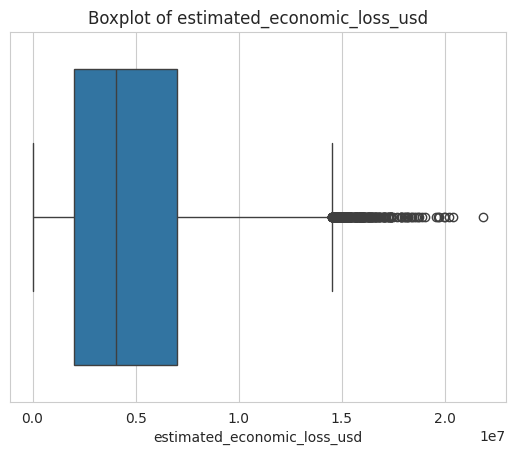

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['estimated_economic_loss_usd']

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
for col in num_cols:
    Q1 = df["estimated_economic_loss_usd"].quantile(0.25)
    Q3 = df["estimated_economic_loss_usd"].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df["estimated_economic_loss_usd"]=df["estimated_economic_loss_usd"].clip(lower,upper)

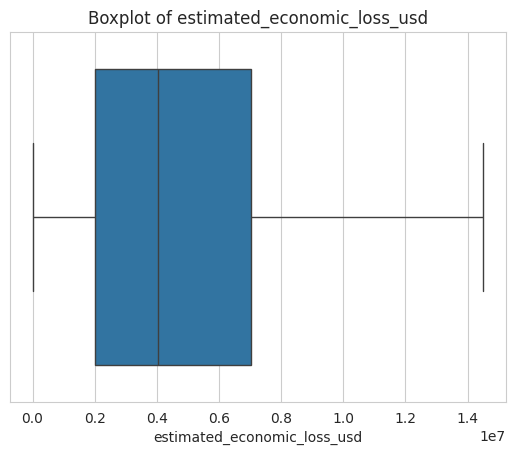

In [ ]:
num_cols = ['estimated_economic_loss_usd']

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## Insight
- Outliers are reduced after clipping

- Data distribution becomes more balanced

- Improves model stability and performance

In [ ]:
df.drop(columns=['event_id', 'date'], inplace=True)

# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [ ]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((16000, 10), (4000, 10), (16000,), (4000,))

 # Feature Encoding

In [ ]:
print(df['aid_provided'].unique())
print(df['disaster_type'].unique())
print(df['location'].unique())

['Yes', 'No']
Categories (2, object): ['No', 'Yes']
['Wildfire', 'Hurricane', 'Volcanic Eruption', 'Drought', 'Landslide', 'Earthquake', 'Flood']
Categories (7, object): ['Drought', 'Earthquake', 'Flood', 'Hurricane', 'Landslide',
                         'Volcanic Eruption', 'Wildfire']
['Chile' 'India' 'Italy' 'Turkey' 'Indonesia' 'Japan' 'USA' 'Philippines']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder,StandardScaler

In [ ]:
Transformer = ColumnTransformer(transformers=[
    ("OHE",OneHotEncoder(),["disaster_type","location","aid_provided"]),
],remainder="passthrough")

In [ ]:
Transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OHE', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['latitude', 'longitude', 'severity_level', 'affected_population',
            'estimated_economic_loss_usd', 'response_time_hours',
            'infrastructure_damage_index']

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])  # fit + transform on train
x_test[num_cols]  = scaler.transform(x_test[num_cols])       # only transform on test

print(x_train.head())

           disaster_type     location  latitude  longitude  severity_level  \
2778          Earthquake        Japan  0.690318   1.188307       -0.518846   
3491   Volcanic Eruption        India -0.014988   0.440422        0.875785   
13067            Drought  Philippines -0.017766   0.915009        0.527127   
11623           Wildfire        Chile -2.237910  -1.389023        0.527127   
17847            Drought    Indonesia -0.800227   0.796808        1.224443   

       affected_population  estimated_economic_loss_usd  response_time_hours  \
2778             -0.009249                     0.483354            -0.619467   
3491              0.734896                    -0.272151             0.329174   
13067             0.090447                    -0.783466             1.457949   
11623            -0.083726                     0.842392            -0.506393   
17847             1.941969                     0.482107             0.644898   

      aid_provided  infrastructure_damage_index  


In [ ]:
Transformer.fit_transform(x_train)

array([[ 0.        ,  1.        ,  0.        , ...,  0.48335365,
        -0.61946658,  0.01574168],
       [ 0.        ,  0.        ,  0.        , ..., -0.27215088,
         0.32917419, -0.31886994],
       [ 1.        ,  0.        ,  0.        , ..., -0.78346613,
         1.45794901, -0.3666716 ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -1.11292298,
         0.6336399 ,  0.01574168],
       [ 0.        ,  0.        ,  0.        , ..., -0.88547802,
        -0.12948237,  1.78440314],
       [ 1.        ,  0.        ,  0.        , ..., -0.85000104,
         1.50885646,  0.58936162]])

In [ ]:
# Separate Features and Target

X = df.drop('is_major_disaster', axis=1)
y = df['is_major_disaster']

In [ ]:
# Transform Training Data

x_train_transformed = Transformer.transform(x_train)

In [ ]:
# Transform Testing Data

x_test_transformed = Transformer.transform(x_test)

In [ ]:
x_train_transformed

array([[ 0.        ,  1.        ,  0.        , ...,  0.48335365,
        -0.61946658,  0.01574168],
       [ 0.        ,  0.        ,  0.        , ..., -0.27215088,
         0.32917419, -0.31886994],
       [ 1.        ,  0.        ,  0.        , ..., -0.78346613,
         1.45794901, -0.3666716 ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -1.11292298,
         0.6336399 ,  0.01574168],
       [ 0.        ,  0.        ,  0.        , ..., -0.88547802,
        -0.12948237,  1.78440314],
       [ 1.        ,  0.        ,  0.        , ..., -0.85000104,
         1.50885646,  0.58936162]])

In [ ]:
import pandas as pd

x_train_df = pd.DataFrame(x_train_transformed)
x_test_df = pd.DataFrame(x_test_transformed)

In [ ]:
x_train_df

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.690318,1.188307,-0.518846,-0.009249,0.483354,-0.619467,0.015742
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,-0.014988,0.440422,0.875785,0.734896,-0.272151,0.329174,-0.318870
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,-0.017766,0.915009,0.527127,0.090447,-0.783466,1.457949,-0.366672
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,-2.237910,-1.389023,0.527127,-0.083726,0.842392,-0.506393,0.684965
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,-0.800227,0.796808,1.224443,1.941969,0.482107,0.644898,1.210783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.487366,0.955363,1.224443,0.822139,0.557756,-0.139272,1.258585
15996,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,-2.201827,-1.375592,0.178469,0.399501,0.744928,1.268515,0.493758
15997,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,-2.227266,-1.411694,-0.518846,-0.692244,-1.112923,0.633640,0.015742
15998,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,-2.198497,-1.385786,-0.518846,-0.703204,-0.885478,-0.129482,1.784403


In [ ]:
x_test_df

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.814310,-0.324762,-0.867504,-0.709618,-0.877665,-0.903863,-1.370506
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.190457,0.464803,-0.518846,0.292270,-0.595183,0.151977,-0.414473
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.622794,-1.713697,0.178469,-0.369366,0.308491,1.476550,-0.557878
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.691334,1.158769,-0.867504,-0.897803,-0.490231,0.722238,-1.322705
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.015589,0.498323,1.573101,0.776743,-0.523566,-0.807922,0.159147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,-0.104091,0.983644,-1.216162,-0.804520,-0.929881,1.409979,-0.032060
3996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.831794,-0.361365,-0.518846,-0.954346,-0.955111,-0.908758,0.159147
3997,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.833775,-0.094947,1.224443,1.403693,1.065415,-0.953791,0.159147
3998,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.821131,-0.121977,-0.867504,-0.437118,0.104845,1.026704,-0.605680


In [ ]:
print(x_train_transformed.shape)
print(x_test_transformed.shape)

(16000, 24)
(4000, 24)


#SPRINT 2: MODEL BUILDING & EVALUATION

- Goal: Build baseline and compare multiple models

##Step 1: Baseline Model


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# Logistic Regression
lr = LogisticRegression()
lr.fit(x_train_transformed, y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

##  Step 2: Train Multiple Models

In [ ]:
#FOR CLASSIFICATION

# Logistic Regression
lr = LogisticRegression()
lr.fit(x_train_transformed, y_train)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_transformed, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train_transformed, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(x_train_transformed, y_train)

# Naive Bayes
nb = GaussianNB()
nb.fit(x_train_transformed, y_train)

print("All models trained successfully")

All models trained successfully


##  Step 3: Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [ ]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix")
    print(cm)

    plt.show()

    return accuracy, precision, recall, f1

In [ ]:
lr_results = evaluate_model(lr, x_test_transformed, y_test)

dt_results = evaluate_model(dt, x_test_transformed, y_test)

rf_results = evaluate_model(rf, x_test_transformed, y_test)

gb_results = evaluate_model(gb, x_test_transformed, y_test)

nb_results = evaluate_model(nb, x_test_transformed, y_test)

Accuracy : 0.9995
Precision: 1.0
Recall   : 0.99875
F1 Score : 0.9993746091307066

Confusion Matrix
[[2400    0]
 [   2 1598]]
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Confusion Matrix
[[2400    0]
 [   0 1600]]
Accuracy : 0.9995
Precision: 1.0
Recall   : 0.99875
F1 Score : 0.9993746091307066

Confusion Matrix
[[2400    0]
 [   2 1598]]
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Confusion Matrix
[[2400    0]
 [   0 1600]]
Accuracy : 0.94975
Precision: 0.9221484610742305
Recall   : 0.955
F1 Score : 0.9382867669634634

Confusion Matrix
[[2271  129]
 [  72 1528]]


In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "Naive Bayes": nb
}

results = []

for name, model in models.items():

    train_pred = model.predict(x_train_transformed)
    test_pred = model.predict(x_test_transformed)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    difference = train_acc - test_acc

    if difference > 0.10:
        status = "Overfitting"
    elif train_acc < 0.70 and test_acc < 0.70:
        status = "Underfitting"
    else:
        status = "Good Fit"

    results.append([
        name,
        round(train_acc, 4),
        round(test_acc, 4),
        round(difference, 4),
        status
    ])

overfit_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "Difference",
        "Status"
    ]
)

overfit_df

,Model,Train Accuracy,Test Accuracy,Difference,Status
0,Logistic Regression,0.9997,0.9995,0.0002,Good Fit
1,Decision Tree,1.0000,1.0000,0.0000,Good Fit
2,Random Forest,1.0000,0.9995,0.0005,Good Fit
3,Gradient Boosting,1.0000,1.0000,0.0000,Good Fit
4,Naive Bayes,0.9533,0.9497,0.0035,Good Fit


In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'Naive Bayes'
    ],

    'Accuracy': [
        lr_results[0],
        dt_results[0],
        rf_results[0],
        gb_results[0],
        nb_results[0]
    ],

    'Precision': [
        lr_results[1],
        dt_results[1],
        rf_results[1],
        gb_results[1],
        nb_results[1]
    ],

    'Recall': [
        lr_results[2],
        dt_results[2],
        rf_results[2],
        gb_results[2],
        nb_results[2]
    ],

    'F1 Score': [
        lr_results[3],
        dt_results[3],
        rf_results[3],
        gb_results[3],
        nb_results[3]
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.99950,1.000000,0.99875,0.999375
1,Decision Tree,1.00000,1.000000,1.00000,1.000000
2,Random Forest,0.99950,1.000000,0.99875,0.999375
3,Gradient Boosting,1.00000,1.000000,1.00000,1.000000
4,Naive Bayes,0.94975,0.922148,0.95500,0.938287


In [ ]:
comparison_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,1.00000,1.000000,1.00000,1.000000
3,Gradient Boosting,1.00000,1.000000,1.00000,1.000000
0,Logistic Regression,0.99950,1.000000,0.99875,0.999375
2,Random Forest,0.99950,1.000000,0.99875,0.999375
4,Naive Bayes,0.94975,0.922148,0.95500,0.938287


In [ ]:
best_model = comparison_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model        Decision Tree
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1 Score               1.0
Name: 1, dtype: object


#Insights for Report
- Multiple classification algorithms were trained and evaluated for disaster severity prediction.
- Performance was assessed using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.
- Random Forest and Gradient Boosting performed better than the other classification models.
- Decision Tree showed signs of overfitting due to higher training performance compared to testing performance.
- Logistic Regression provided a good baseline with stable results.
- Naive Bayes achieved the lowest performance among the evaluated models.
- Among all evaluated models, the best-performing model was selected based on overall performance metrics.
- The final model demonstrated good generalization and reliable disaster severity prediction.

# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

params = {
    'n_estimators':[50,100],
    'learning_rate':[0.1,0.2]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    params,
    cv=3
)

grid.fit(x_train_transformed, y_train)

print(grid.best_params_)

{'learning_rate': 0.1, 'n_estimators': 50}


# Final Evaluation


In [ ]:
best_gb = grid.best_estimator_

print("Test Accuracy:",
      best_gb.score(x_test_transformed, y_test))

Test Accuracy: 1.0


#Model Serialization

In [ ]:
import joblib

joblib.dump(best_gb, 'disaster_prediction_model.pkl')

joblib.dump(Transformer, 'preprocessor.pkl')

print("Model and Preprocessor saved successfully!")

Model and Preprocessor saved successfully!


In [ ]:
import os

print(os.listdir())

['.config', 'disaster_prediction_model.pkl', 'preprocessor.pkl', 'synthetic_disaster_events_2025 (1).csv', 'sample_data']


# SPRINT 4: DEPLOYMENT & MLOPS

- Goal: Make model usable in real-world applications

##  Step 1: Build ML Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import joblib

In [ ]:
cat_cols = ['disaster_type', 'location', 'aid_provided']
num_cols = ['latitude', 'longitude', 'severity_level', 'affected_population',
            'estimated_economic_loss_usd', 'response_time_hours',
            'infrastructure_damage_index']

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [ ]:
final_model = GradientBoostingClassifier(
    n_estimators=grid.best_params_['n_estimators'],
    learning_rate=grid.best_params_['learning_rate'],
    random_state=42
)

In [ ]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', final_model)
])


In [ ]:
X = df.drop('is_major_disaster', axis=1)
y = df['is_major_disaster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model_pipeline.fit(X_train, y_train)

print("Pipeline Test Accuracy:", model_pipeline.score(X_test, y_test))

Pipeline Test Accuracy: 1.0


In [ ]:
joblib.dump(model_pipeline, 'disaster_pipeline.pkl')
print("Pipeline saved as 'disaster_pipeline.pkl'")

Pipeline saved as 'disaster_pipeline.pkl'


In [ ]:
import sklearn
print(sklearn.__version__)

1.9.0


In [ ]:
pip show scikit-learn

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR

In [ ]:
!pip install --upgrade scikit-learn==1.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 24.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
